In [1]:
#@bigquery
## Reading Amazon Reviews Final Project - Step 2 Analysis

In [1]:
import sys
print(sys.version)
print(spark.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:38:13) [GCC 12.3.0]
3.5.1


In [2]:
# timeline analysis
from pyspark.sql import SparkSession
gcs_path = "gs://msca-bdp-students-bucket/notebooks/jiayue1/reviews_meta_final_parquet/"
df_clean = spark.read.parquet(gcs_path)
df_clean.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- product_title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_avg_rating: double (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)



In [3]:
df_clean

DataFrame[parent_asin: string, asin: string, helpful_vote: bigint, rating: double, text: string, timestamp: bigint, title: string, user_id: string, verified_purchase: boolean, product_title: string, store: string, main_category: string, product_avg_rating: double, categories: array<string>, price: string]

In [4]:
from pyspark.sql.functions import col, from_unixtime, to_date, min, max, year, date_format, count
import datetime

# --- 1. CONVERT MILLISECONDS TO SECONDS ---
# Create a new column with the timestamp converted to seconds
df_seconds = df_clean.withColumn(
    "timestamp_sec", 
    col("timestamp") / 1000
)

# Define a safe maximum timestamp in seconds (Jan 1, 2040)
# This is a safe guard against any remaining numeric garbage
MAX_SAFE_TIMESTAMP_SECONDS = 2208988800 

# 2. Filter Extreme Outliers & Convert to Date
df_timeline_clean = df_seconds.filter(
    (col("timestamp_sec").isNotNull()) & 
    (col("timestamp_sec") < MAX_SAFE_TIMESTAMP_SECONDS) 
).withColumn(
    "review_date", 
    to_date(from_unixtime(col("timestamp_sec"))) # Use the new 'timestamp_sec' column
).filter(
    # Filter out any remaining dates that are too old (e.g., pre-2000)
    (col("review_date").isNotNull()) & 
    (year(col("review_date")) >= 2000)
)

# 3. Find the Absolute Earliest and Latest Dates (Range Check)
date_range = df_timeline_clean.agg(
    min(col("review_date")).alias("min_date"),
    max(col("review_date")).alias("max_date")
).collect()[0]

print(f"**Absolute Earliest Review Date (Cleaned):** {date_range['min_date']}")
print(f"**Absolute Latest Review Date (Cleaned):** {date_range['max_date']}")

**Absolute Earliest Review Date (Cleaned):** 2000-01-07
**Absolute Latest Review Date (Cleaned):** 2023-09-13


In [6]:
from pyspark.sql.functions import year, month, count
import pandas as pd
monthly_reviews = df_timeline_clean.groupBy(
    year("review_date").alias("year"),
    month("review_date").alias("month")
).agg(
    count("*").alias("review_count")
).orderBy("year", "month")

monthly_df = monthly_reviews.toPandas()
monthly_df['date'] = pd.to_datetime(monthly_df[['year', 'month']].assign(day=1))

print(f"Total months: {len(monthly_df)}")
monthly_df.head()

Total months: 285


,year,month,review_count,date
0,2000,1,7,2000-01-01
1,2000,2,7,2000-02-01
2,2000,3,4,2000-03-01
3,2000,4,9,2000-04-01
4,2000,5,4,2000-05-01


In [13]:
monthly_df['days_to_next'] = monthly_df['date'].diff().shift(-1).dt.days
gaps = monthly_df[monthly_df['days_to_next'] > 35]

if len(gaps) > 0:
    print(f"Data gaps detected: {len(gaps)}\n")
    for _, row in gaps.iterrows():
        print(f"  After {row['date'].strftime('%Y-%m')}: ~{row['days_to_next']:.0f} days")
else:
    print("No significant gaps detected")

No significant gaps detected


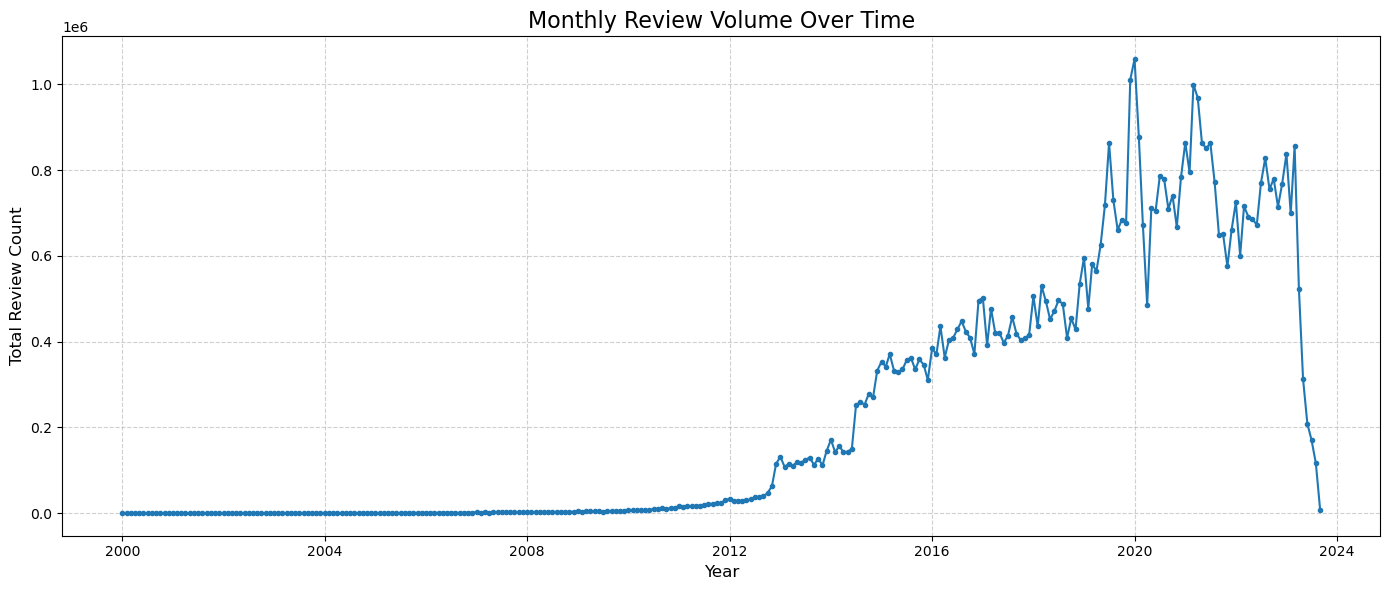

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

df_monthly_counts_pd['datetime'] = pd.to_datetime(df_monthly_counts_pd['review_month'], format='%Y-%m')

plt.figure(figsize=(14, 6))
plt.plot(df_monthly_counts_pd['datetime'], df_monthly_counts_pd['review_count'], 
         marker='o', markersize=3, linestyle='-', linewidth=1.5, color='#1f77b4') 

plt.title('Monthly Review Volume Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Review Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
mean_count = monthly_df['review_count'].mean()
std_count = monthly_df['review_count'].std()

monthly_df['is_peak'] = monthly_df['review_count'] > (mean_count + 1.5 * std_count)
monthly_df['is_valley'] = monthly_df['review_count'] < (mean_count - 1.5 * std_count)

peaks = monthly_df[monthly_df['is_peak']]
valleys = monthly_df[monthly_df['is_valley']]

print(f"Mean: {mean_count:,.0f} | Std: {std_count:,.0f}")
print(f"\nPeaks detected: {len(peaks)}")
print(f"Valleys detected: {len(valleys)}")

Mean: 224,451 | Std: 290,947

Peaks detected: 39
Valleys detected: 0


In [16]:
print("Top 5 Peaks:")
for _, row in peaks.nlargest(5, 'review_count').iterrows():
    print(f"  {row['date'].strftime('%Y-%m')}: {row['review_count']:,} reviews")

print("\nTop 5 Valleys:")
for _, row in valleys.nsmallest(5, 'review_count').iterrows():
    print(f"  {row['date'].strftime('%Y-%m')}: {row['review_count']:,} reviews")

Top 5 Peaks:
  2020-01: 1,059,194 reviews
  2019-12: 1,010,944 reviews
  2021-03: 999,663 reviews
  2021-04: 968,703 reviews
  2020-02: 876,721 reviews

Top 5 Valleys:


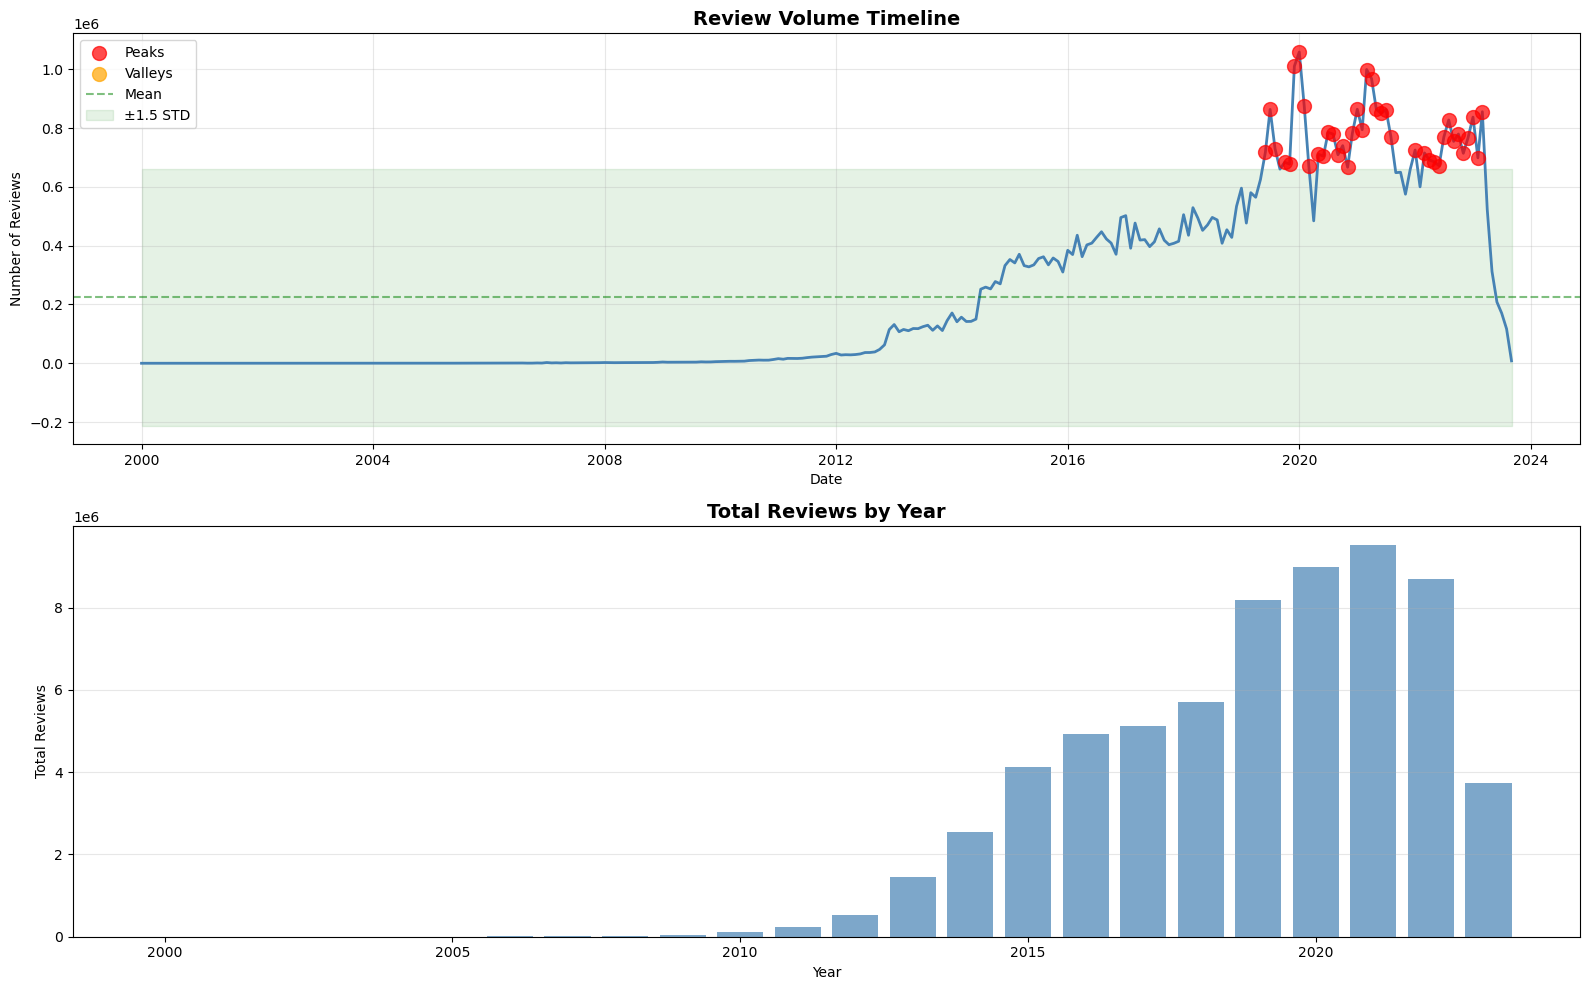

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Monthly timeline
ax1.plot(monthly_df['date'], monthly_df['review_count'], linewidth=2, color='steelblue')
ax1.scatter(peaks['date'], peaks['review_count'], color='red', s=100, 
            label='Peaks', zorder=5, alpha=0.7)
ax1.scatter(valleys['date'], valleys['review_count'], color='orange', s=100, 
            label='Valleys', zorder=5, alpha=0.7)
ax1.axhline(y=mean_count, color='green', linestyle='--', alpha=0.5, label='Mean')
ax1.fill_between(monthly_df['date'], 
                  mean_count - 1.5*std_count, 
                  mean_count + 1.5*std_count, 
                  alpha=0.1, color='green', label='±1.5 STD')
ax1.set_title('Review Volume Timeline', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Reviews')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Yearly aggregation
yearly_df = monthly_df.groupby(monthly_df['date'].dt.year)['review_count'].sum().reset_index()
yearly_df.columns = ['year', 'total_reviews']

ax2.bar(yearly_df['year'], yearly_df['total_reviews'], color='steelblue', alpha=0.7)
ax2.set_title('Total Reviews by Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Reviews')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [19]:
from pyspark.sql.functions import col, avg, desc
top_products = df_timeline_clean.groupBy('asin', 'product_title').agg(
    count('*').alias('review_count'),
    avg('rating').alias('avg_rating')
).orderBy(desc('review_count')).limit(10)

top_products_pd = top_products.toPandas()

print('Top 10 Products by Review Count:\n')
for i, row in top_products_pd.iterrows():
    title = str(row['product_title'])[:60] + '...' if len(str(row['product_title'])) > 60 else row['product_title']
    print(f'{i+1}. {title}')
    print(f"   ASIN: {row['asin']}")
    print(f"   Reviews: {row['review_count']:,} | Avg Rating: {row['avg_rating']:.2f}\n")

Top 10 Products by Review Count:

1. amFilm Screen Protector 4.7“ for Apple iPhone 8, iPhone 7, i...
   ASIN: B01415QHYW
   Reviews: 42,771 | Avg Rating: 4.29

2. REVLON One-Step Volumizer Original 1.0 Hair Dryer and Hot Ai...
   ASIN: B01LSUQSB0
   Reviews: 36,823 | Avg Rating: 4.34

3. essence | Lash Princess False Lash Effect Mascara | Gluten &...
   ASIN: B00T0C9XRK
   Reviews: 32,748 | Avg Rating: 3.99

4. HSI Professional Glider Ceramic Flat Iron Hair Straightener ...
   ASIN: B001MA0QY2
   Reviews: 27,299 | Avg Rating: 4.30

5. Yootech Wireless Charger,10W Max Fast Wireless Charging Pad ...
   ASIN: B079KZ49PJ
   Reviews: 25,776 | Avg Rating: 4.01

6. Beam Electronics Car Phone Holder Mount, Phone Car Air Vent ...
   ASIN: B073R68TSH
   Reviews: 25,390 | Avg Rating: 4.37

7. Ailun Glass Screen Protector Compatible for iPhone 11/XR,6.1...
   ASIN: B07H2V5YLH
   Reviews: 24,529 | Avg Rating: 4.09

8. Ailun Screen Protector Compatible for iPhone 8 plus,7 Plus,6...
   ASIN: B01LXZDP

In [21]:
top_asins = [row['asin'] for row in top_products.collect()]

top_product_trends = df_timeline_clean.filter(
    col('asin').isin(top_asins)
).groupBy(
    'asin', 'product_title',
    year('review_date').alias('year'),
    month('review_date').alias('month')
).agg(
    count('*').alias('review_count')
).orderBy('asin', 'year', 'month')

trends_pd = top_product_trends.toPandas()
trends_pd['date'] = pd.to_datetime(trends_pd[['year', 'month']].assign(day=1))

print(f'Trend data points: {len(trends_pd)}')

Trend data points: 864


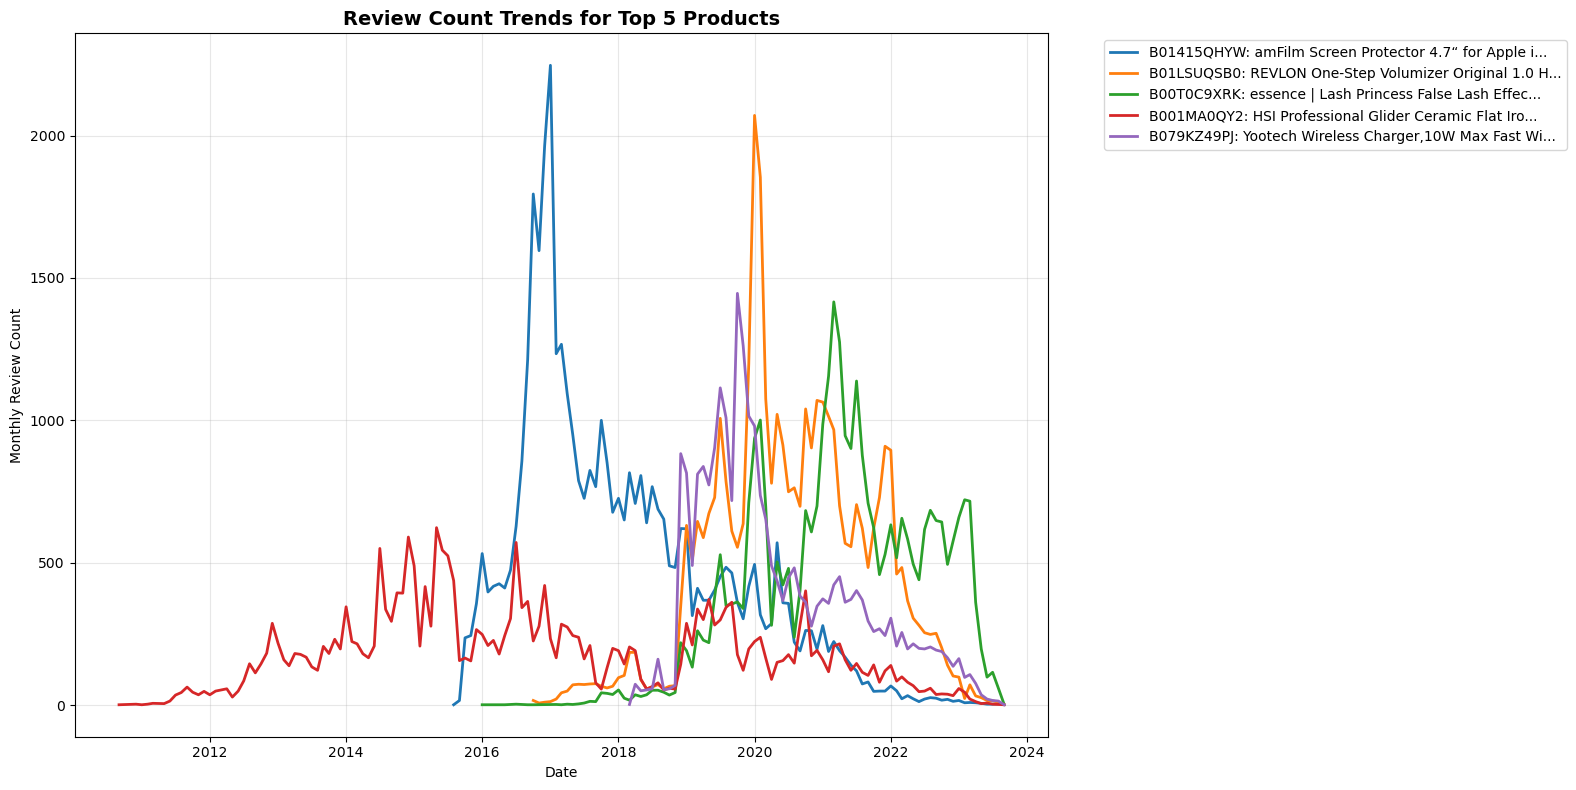

In [24]:
fig, ax = plt.subplots(figsize=(16, 8))

for asin in top_asins[:5]:
    product_data = trends_pd[trends_pd['asin'] == asin]
    product_title = product_data['product_title'].iloc[0]
    title_short = str(product_title)[:40] + '...' if len(str(product_title)) > 40 else product_title
    ax.plot(product_data['date'], product_data['review_count'], 
            marker='None', label=f'{asin}: {title_short}', linewidth=2)

ax.set_title('Review Count Trends for Top 5 Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Review Count')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

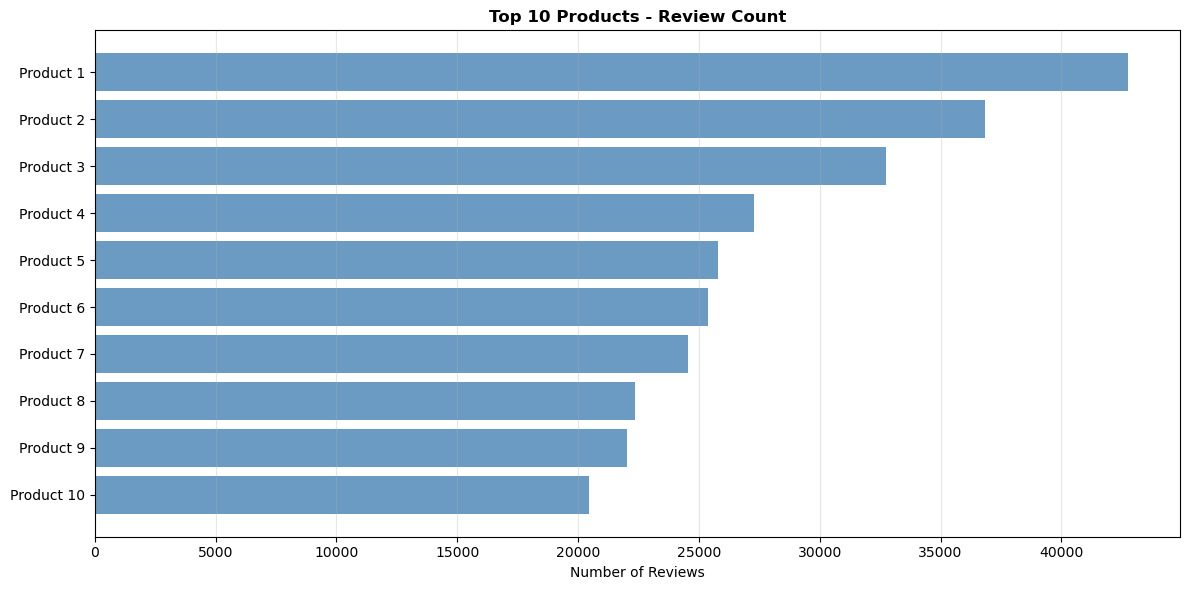

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(range(len(top_products_pd)), top_products_pd['review_count'], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_products_pd)))
ax.set_yticklabels([f'Product {i+1}' for i in range(len(top_products_pd))])
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 10 Products - Review Count', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

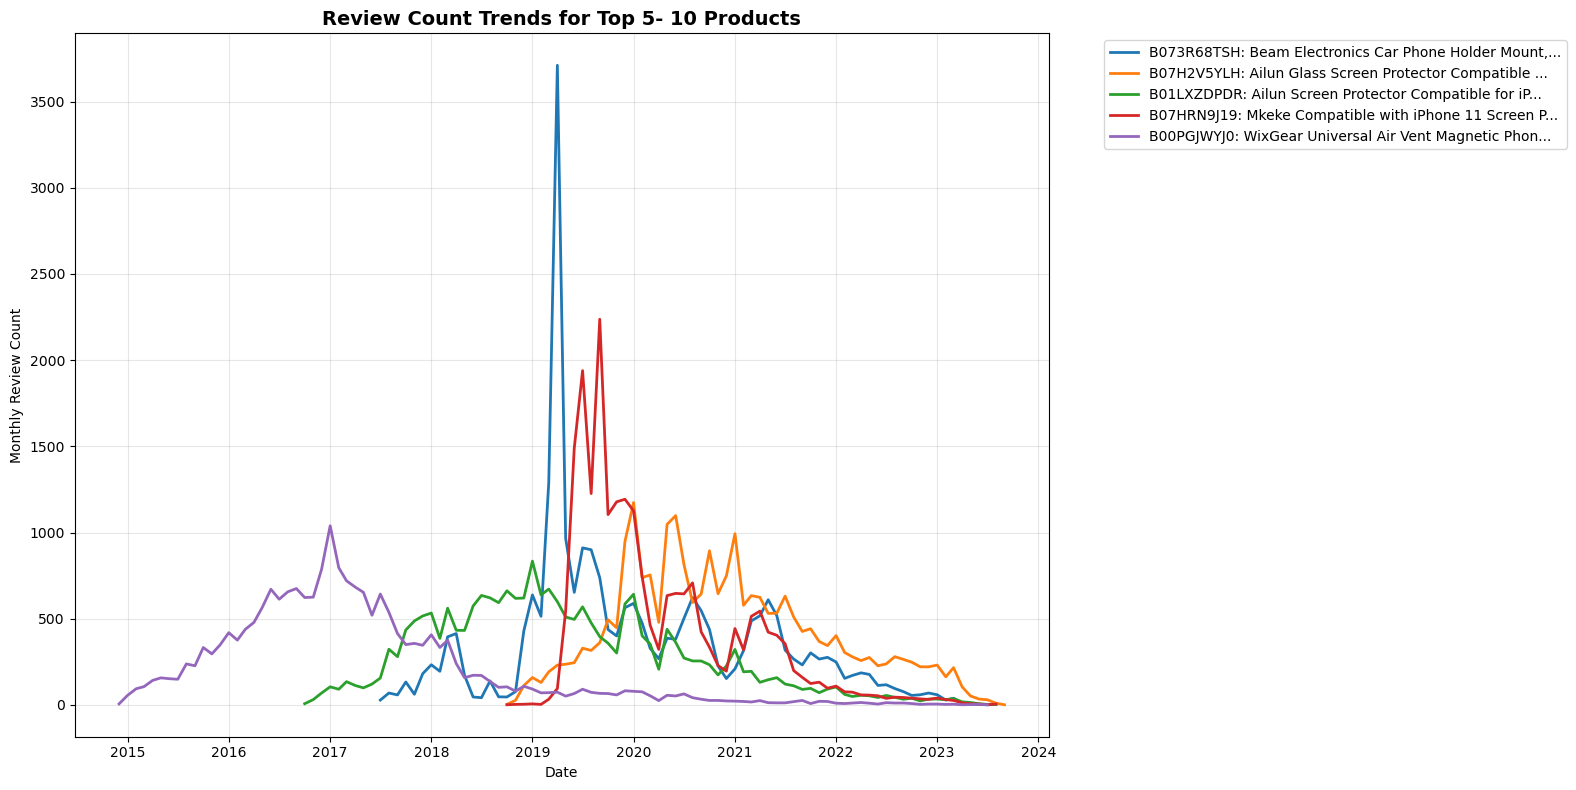

In [26]:
fig, ax = plt.subplots(figsize=(16, 8))

for asin in top_asins[5:]:
    product_data = trends_pd[trends_pd['asin'] == asin]
    product_title = product_data['product_title'].iloc[0]
    title_short = str(product_title)[:40] + '...' if len(str(product_title)) > 40 else product_title
    ax.plot(product_data['date'], product_data['review_count'], 
            marker='None', label=f'{asin}: {title_short}', linewidth=2)

ax.set_title('Review Count Trends for Top 5- 10 Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Review Count')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from pyspark.sql.functions import col, avg, desc
category_volume = df_timeline_clean.groupBy('main_category').agg(
    count('*').alias('review_count'),
    avg('rating').alias('avg_rating')
).orderBy(desc('review_count'))

category_pd = category_volume.toPandas()

print('Top 10 Categories:\n')
for i, row in category_pd.head(10).iterrows():
    print(f"{i+1}. {row['main_category']}: {row['review_count']:,} reviews | Avg Rating: {row['avg_rating']:.2f}")

Top 10 Categories:

1. All Beauty: 18,341,426 reviews | Avg Rating: 4.11
2. Cell Phones & Accessories: 17,324,175 reviews | Avg Rating: 4.01
3. Automotive: 16,704,039 reviews | Avg Rating: 4.19
4. Health & Personal Care: 2,048,820 reviews | Avg Rating: 4.14
5. All Electronics: 1,725,693 reviews | Avg Rating: 4.08
6. Premium Beauty: 1,348,848 reviews | Avg Rating: 4.11
7. None: 1,185,438 reviews | Avg Rating: 4.08
8. Amazon Home: 1,140,072 reviews | Avg Rating: 4.09
9. Tools & Home Improvement: 1,075,513 reviews | Avg Rating: 4.17
10. AMAZON FASHION: 804,167 reviews | Avg Rating: 4.14


In [9]:
top_categories = [row['main_category'] for row in category_volume.collect()[:5]]

category_monthly = df_timeline_clean.filter(
    col('main_category').isin(top_categories)
).groupBy(
    'main_category',
    year('review_date').alias('year'),
    month('review_date').alias('month')
).agg(count('*').alias('review_count')).orderBy('main_category', 'year', 'month')

category_monthly_pd = category_monthly.toPandas()
category_monthly_pd['date'] = pd.to_datetime(category_monthly_pd[['year', 'month']].assign(day=1))

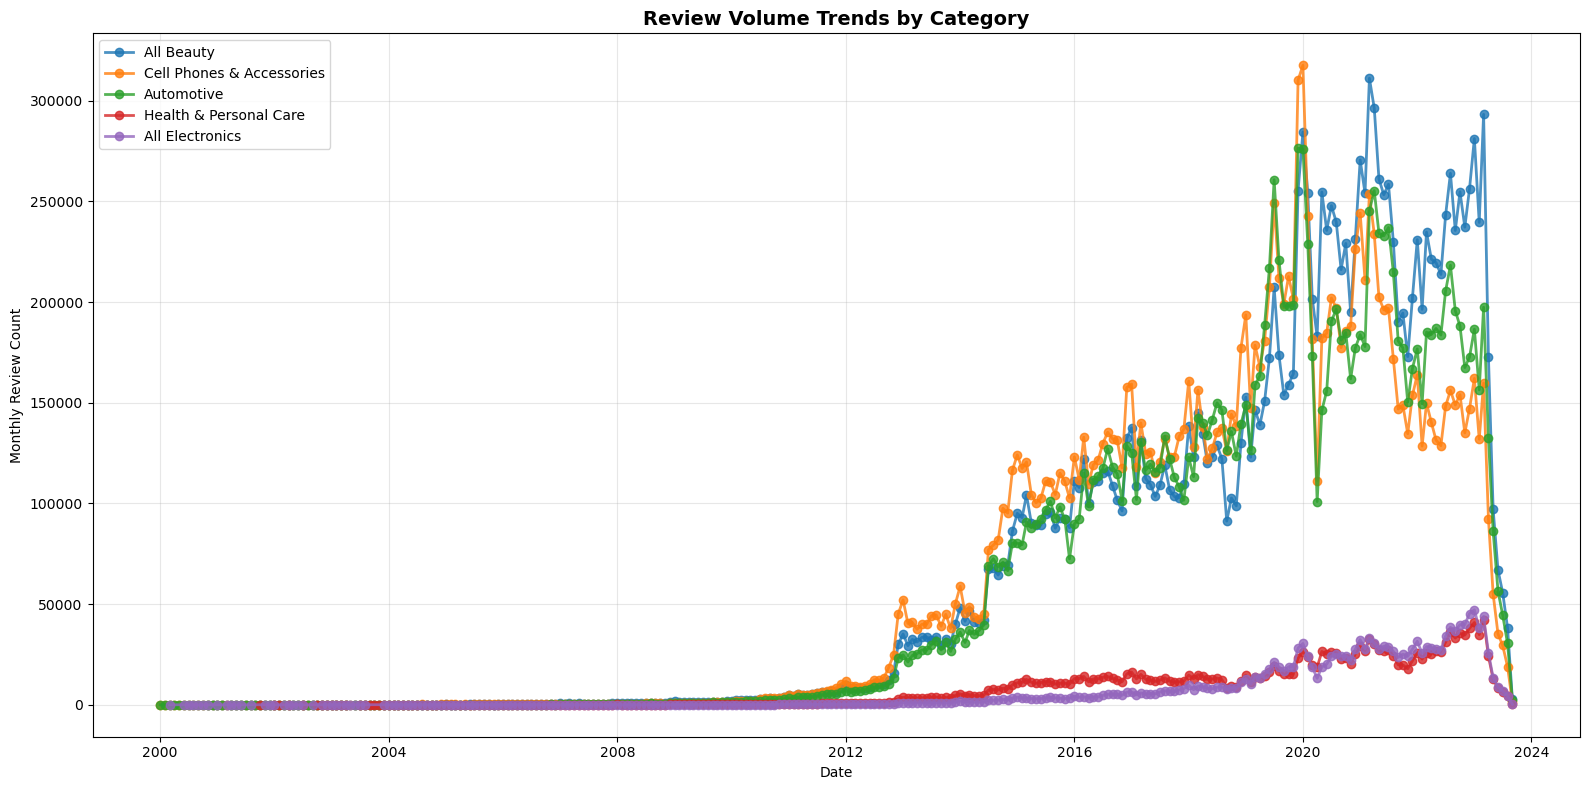

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(16, 8))

for category in top_categories:
    cat_data = category_monthly_pd[category_monthly_pd['main_category'] == category]
    ax.plot(cat_data['date'], cat_data['review_count'], 
            marker='o', label=category, linewidth=2, alpha=0.8)

ax.set_title('Review Volume Trends by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Review Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

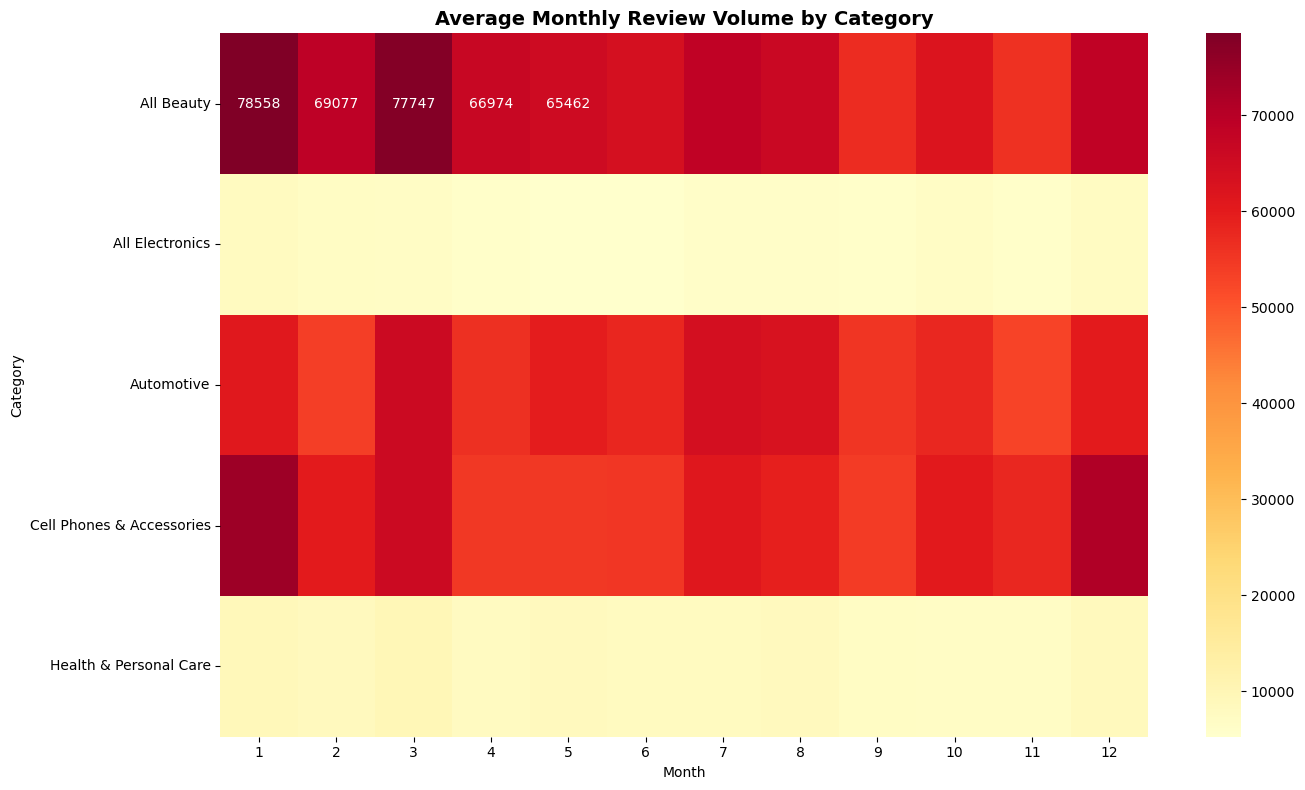

In [12]:
import seaborn as sns
category_monthly_pd['month_only'] = category_monthly_pd['date'].dt.month
seasonal_patterns = category_monthly_pd.groupby(['main_category', 'month_only'])['review_count'].mean().reset_index()
seasonal_pivot = seasonal_patterns.pivot(index='main_category', columns='month_only', values='review_count')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(seasonal_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Monthly Review Volume by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

In [13]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, desc, regexp_replace
df_with_price = df_timeline_clean.withColumn(
    'price_numeric',
    regexp_replace(col('price'), '[^0-9.]', '').cast('double')
)

product_stats = df_with_price.groupBy('asin', 'product_title').agg(
    count('*').alias('review_count'),
    avg('rating').alias('avg_rating'),
    avg('price_numeric').alias('avg_price')
).filter(col('review_count') >= 10)

stats_pd = product_stats.toPandas()

In [14]:
high_rated = stats_pd[stats_pd['avg_rating'] >= 4.9].sort_values('review_count', ascending=False)
print('Products with ratings >= 4.9 (top 10):\n')
for i, row in high_rated.head(10).iterrows():
    title = str(row['product_title'])[:50] + '...' if len(str(row['product_title'])) > 50 else row['product_title']
    print(f'{i+1}. {title}')
    print(f'   Reviews: {row["review_count"]:,} | Rating: {row["avg_rating"]:.2f} | Price: ${row["avg_price"]:.2f}\n')

Products with ratings >= 4.9 (top 10):

380147. OMOTON Adjustable Cell Phone Stand, C2 Aluminum De...
   Reviews: 2,237 | Rating: 4.90 | Price: $12.99

220306. VASSOUL Blackhead Remover Mask, Peel Off Blackhead...
   Reviews: 1,338 | Rating: 4.99 | Price: $nan

313047. OMOTON Adjustable Cell Phone Stand, C2 Aluminum De...
   Reviews: 1,186 | Rating: 4.90 | Price: $12.99

540526. VASSOUL Foot Peel Mask, Feet Callus Remover & Dead...
   Reviews: 948 | Rating: 5.00 | Price: $nan

869702. Genuine Jeep Accessories 82208453AB Hitch Receiver...
   Reviews: 520 | Rating: 4.91 | Price: $15.30

631121. Zizzili Basics Toenail Clippers for Thick or Ingro...
   Reviews: 520 | Rating: 4.93 | Price: $21.49

118194. Honda 17211-Z8B-901 Air Filter
   Reviews: 514 | Rating: 4.92 | Price: $7.40

539749. Kaphio Facial Hair Removal for Women, Rechargeable...
   Reviews: 514 | Rating: 4.93 | Price: $19.99

527467. moveland Seat Belt Bypass Harness Override Compati...
   Reviews: 495 | Rating: 4.91 | Price: 

/opt/dataproc/conda/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


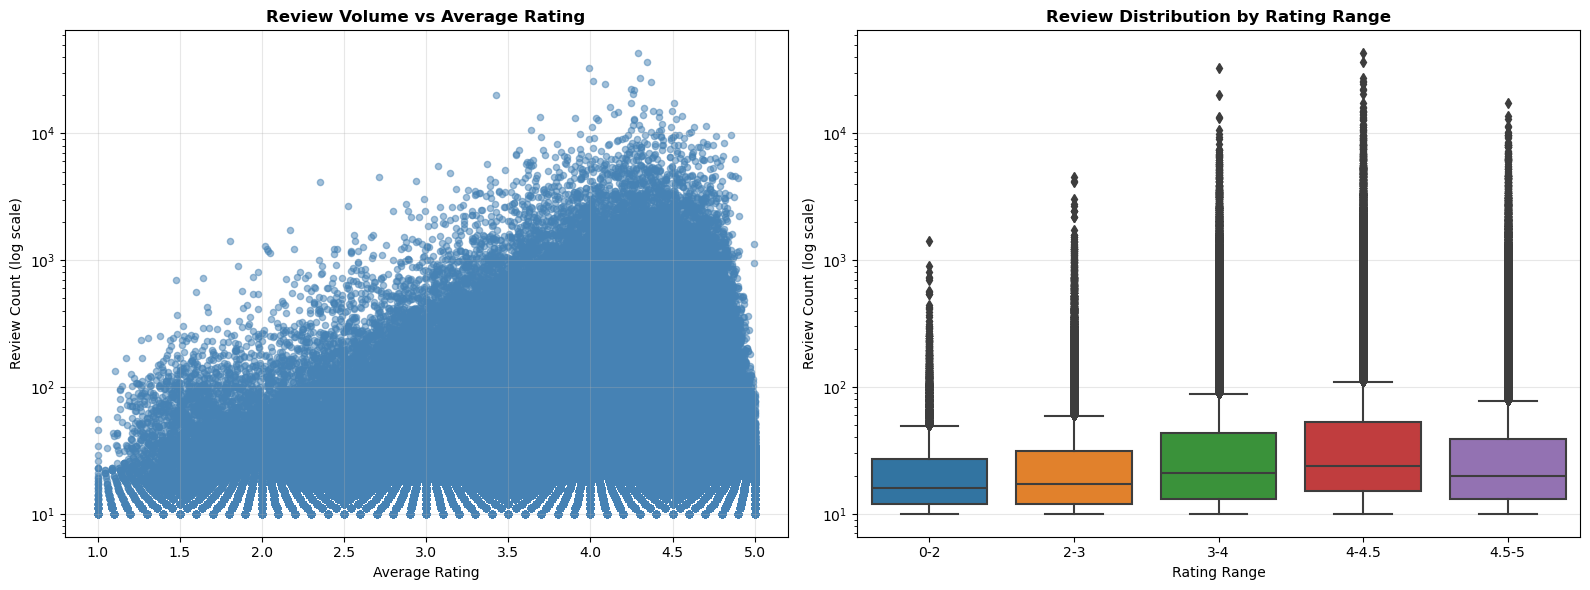

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(stats_pd['avg_rating'], stats_pd['review_count'], alpha=0.5, s=20, color='steelblue')
ax1.set_xlabel('Average Rating')
ax1.set_ylabel('Review Count (log scale)')
ax1.set_yscale('log')
ax1.set_title('Review Volume vs Average Rating', fontweight='bold')
ax1.grid(True, alpha=0.3)

stats_pd['rating_bin'] = pd.cut(stats_pd['avg_rating'], bins=[0, 2, 3, 4, 4.5, 5], labels=['0-2', '2-3', '3-4', '4-4.5', '4.5-5'])
sns.boxplot(data=stats_pd, x='rating_bin', y='review_count', ax=ax2)
ax2.set_yscale('log')
ax2.set_xlabel('Rating Range')
ax2.set_ylabel('Review Count (log scale)')
ax2.set_title('Review Distribution by Rating Range', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

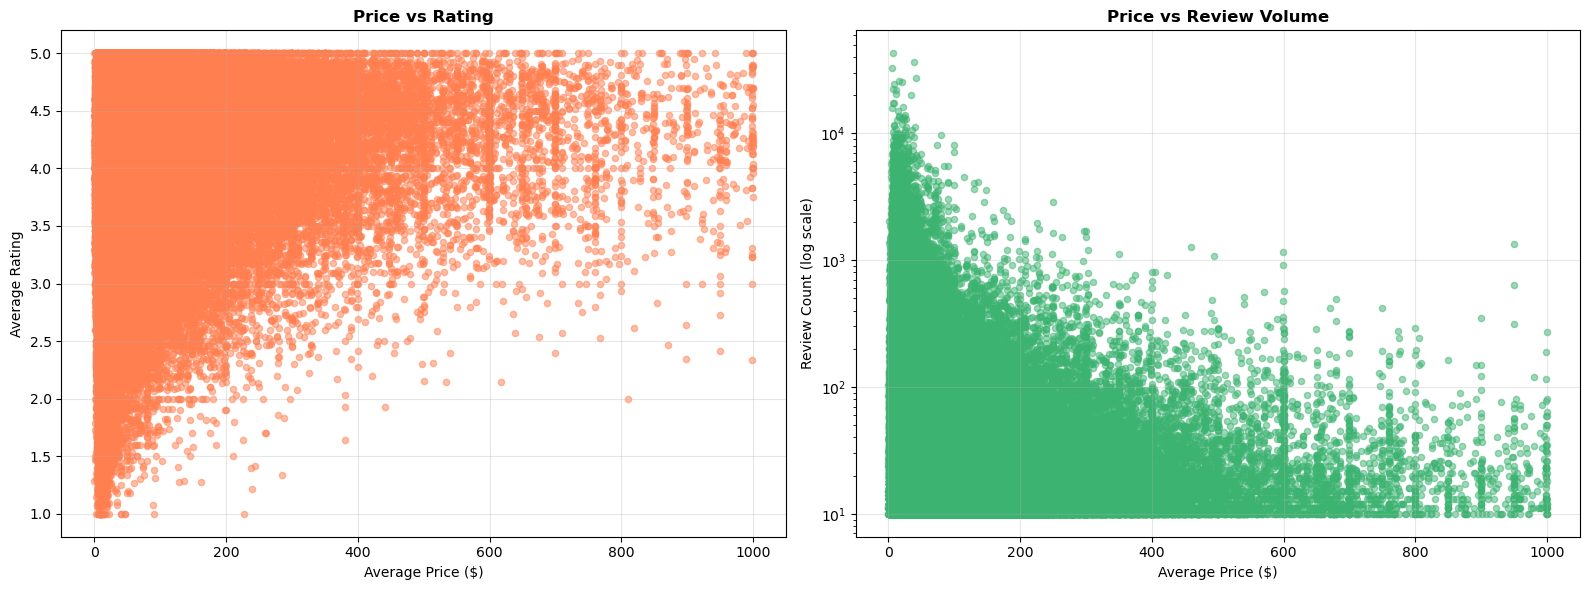

In [16]:
stats_clean = stats_pd[stats_pd['avg_price'].notna() & (stats_pd['avg_price'] > 0) & (stats_pd['avg_price'] < 1000)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(stats_clean['avg_price'], stats_clean['avg_rating'], alpha=0.5, s=20, color='coral')
ax1.set_xlabel('Average Price ($)')
ax1.set_ylabel('Average Rating')
ax1.set_title('Price vs Rating', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.scatter(stats_clean['avg_price'], stats_clean['review_count'], alpha=0.5, s=20, color='mediumseagreen')
ax2.set_xlabel('Average Price ($)')
ax2.set_ylabel('Review Count (log scale)')
ax2.set_yscale('log')
ax2.set_title('Price vs Review Volume', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
five_star = df_timeline_clean.filter(col('rating') == 5.0).sample(False, 0.1).limit(25000)
one_star = df_timeline_clean.filter(col('rating') == 1.0).sample(False, 0.1).limit(25000)

print(f'5-star sample: {five_star.count():,}')
print(f'1-star sample: {one_star.count():,}')

5-star sample: 25,000


1-star sample: 25,000


In [21]:
from pyspark.sql.functions import col, count, desc, explode, lower, regexp_replace, length
from pyspark.ml.feature import Tokenizer, StopWordsRemover

def get_top_words(df, rating_type):
    df_clean = df.withColumn('text_clean', lower(regexp_replace(col('text'), '[^a-zA-Z\\s]', '')))
    tokenizer = Tokenizer(inputCol='text_clean', outputCol='words')
    df_words = tokenizer.transform(df_clean)
    remover = StopWordsRemover(inputCol='words', outputCol='filtered_words')
    df_filtered = remover.transform(df_words)
    word_counts = df_filtered.select(explode(col('filtered_words')).alias('word')).groupBy('word').count().filter(
        (length(col('word')) > 2) & (col('word').rlike('^[a-z]+$'))
    ).orderBy(desc('count')).limit(20)
    return word_counts.toPandas()

print('Analyzing 5-star reviews...')
five_star_words = get_top_words(five_star, '5-star')
print('Analyzing 1-star reviews...')
one_star_words = get_top_words(one_star, '1-star')

Analyzing 5-star reviews...


Analyzing 1-star reviews...


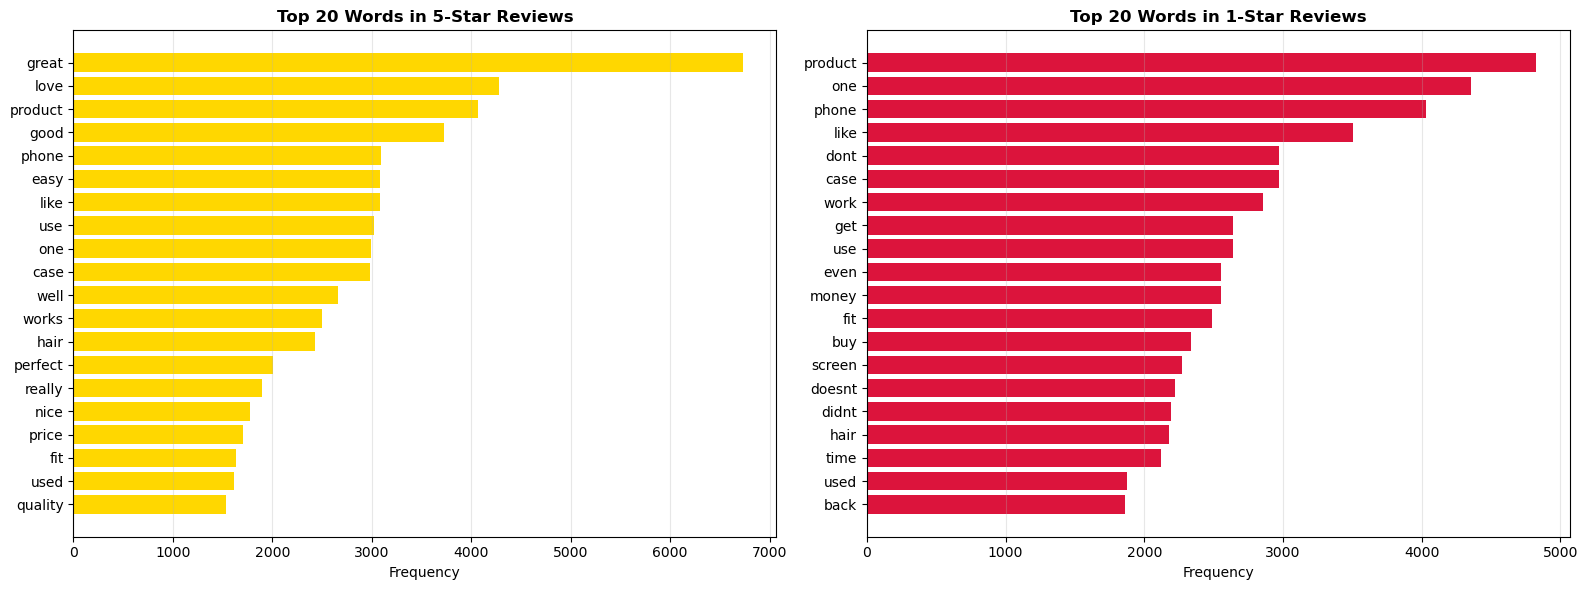

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(five_star_words['word'][::-1], five_star_words['count'][::-1], color='#afc7ff
')
ax1.set_xlabel('Frequency')
ax1.set_title('Top 20 Words in 5-Star Reviews', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

ax2.barh(one_star_words['word'][::-1], one_star_words['count'][::-1], color='green')
ax2.set_xlabel('Frequency')
ax2.set_title('Top 20 Words in 1-Star Reviews', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [23]:
print('Top 10 Words:\n')
print('5-STAR:')
for i, row in five_star_words.head(10).iterrows():
    print(f'  {i+1}. {row["word"]}: {row["count"]:,}')
print('\n1-STAR:')
for i, row in one_star_words.head(10).iterrows():
    print(f'  {i+1}. {row["word"]}: {row["count"]:,}')

Top 10 Words:

5-STAR:
  1. great: 6,732
  2. love: 4,277
  3. product: 4,065
  4. good: 3,725
  5. phone: 3,098
  6. easy: 3,088
  7. like: 3,082
  8. use: 3,025
  9. one: 2,989
  10. case: 2,987

1-STAR:
  1. product: 4,828
  2. one: 4,355
  3. phone: 4,032
  4. like: 3,503
  5. dont: 2,974
  6. case: 2,973
  7. work: 2,853
  8. get: 2,640
  9. use: 2,640
  10. even: 2,556


In [24]:
from pyspark.sql.functions import col, count, countDistinct, avg, desc
top_reviewers = df_timeline_clean.groupBy('user_id').agg(
    count('*').alias('review_count'),
    countDistinct('main_category').alias('category_count'),
    avg('rating').alias('avg_rating')
).orderBy(desc('review_count')).limit(20)

reviewers_pd = top_reviewers.toPandas()

print('Top 20 Most Active Reviewers:\n')
for i, row in reviewers_pd.iterrows():
    print(f"{i+1}. User {row['user_id'][:20]}...")
    print(f"   Reviews: {row['review_count']:,} | Categories: {row['category_count']} | Avg Rating: {row['avg_rating']:.2f}\n")

Top 20 Most Active Reviewers:

1. User AG73BVBKUOH22USSFJA5...
   Reviews: 3,448 | Categories: 24 | Avg Rating: 4.47

2. User AGZUJTI7A3JFKB4FP5JO...
   Reviews: 2,394 | Categories: 14 | Avg Rating: 4.76

3. User AEMP3A7IKW37CMWFXNKX...
   Reviews: 2,328 | Categories: 14 | Avg Rating: 4.08

4. User AFXF3EGQTQDXMRLDWFU7...
   Reviews: 2,031 | Categories: 16 | Avg Rating: 3.68

5. User AH2DN3Q2OKAW7JAFRIYP...
   Reviews: 1,917 | Categories: 13 | Avg Rating: 4.53

6. User AEAXAJACFMXIAAH4WOHR...
   Reviews: 1,849 | Categories: 19 | Avg Rating: 4.69

7. User AEZP6Z2C5AVQDZAJECQY...
   Reviews: 1,784 | Categories: 14 | Avg Rating: 4.13

8. User AFF6DS6NOWRIF2AROFAS...
   Reviews: 1,574 | Categories: 14 | Avg Rating: 4.82

9. User AHV6QCNBJNSGLATP56JA...
   Reviews: 1,480 | Categories: 17 | Avg Rating: 4.30

10. User AGYVC7KVHP2AWM7BDCEY...
   Reviews: 1,358 | Categories: 15 | Avg Rating: 4.54

11. User AF2BLE54TEMGZ546U763...
   Reviews: 1,330 | Categories: 13 | Avg Rating: 4.41

12. User A

In [25]:
diverse = reviewers_pd[reviewers_pd['category_count'] >= 5]
focused = reviewers_pd[reviewers_pd['category_count'] <= 2]

print(f'Diverse reviewers (5+ categories): {len(diverse)} ({len(diverse)/len(reviewers_pd)*100:.1f}%)')
print(f'Focused reviewers (<=2 categories): {len(focused)} ({len(focused)/len(reviewers_pd)*100:.1f}%)')

Diverse reviewers (5+ categories): 20 (100.0%)
Focused reviewers (<=2 categories): 0 (0.0%)


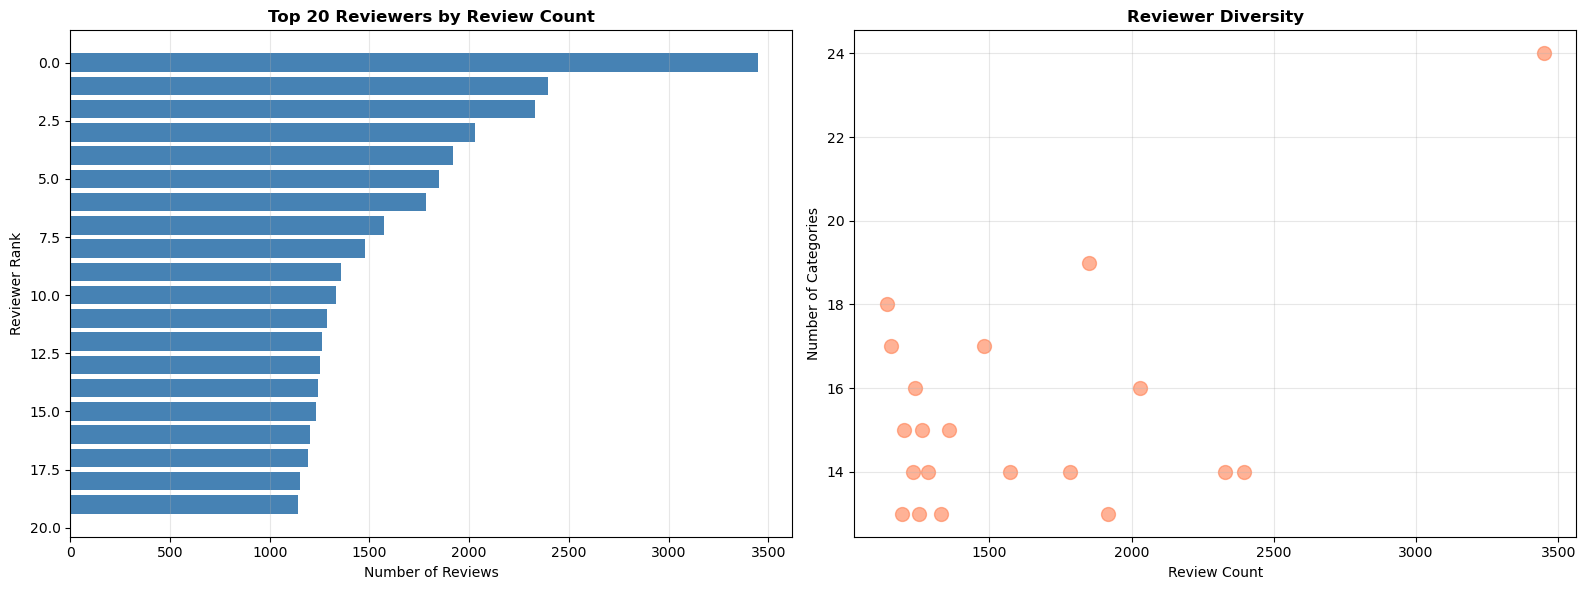

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(range(len(reviewers_pd)), reviewers_pd['review_count'], color='steelblue')
ax1.set_xlabel('Number of Reviews')
ax1.set_ylabel('Reviewer Rank')
ax1.set_title('Top 20 Reviewers by Review Count', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

ax2.scatter(reviewers_pd['review_count'], reviewers_pd['category_count'], s=100, alpha=0.6, color='coral')
ax2.set_xlabel('Review Count')
ax2.set_ylabel('Number of Categories')
ax2.set_title('Reviewer Diversity', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
diverse

,user_id,review_count,category_count,avg_rating
0,AG73BVBKUOH22USSFJA5ZWL7AKXA,3448,24,4.466647
1,AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1,2394,14,4.764829
2,AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,2328,14,4.081186
3,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,2031,16,3.677006
4,AH2DN3Q2OKAW7JAFRIYPHOUOM2ZQ,1917,13,4.531560
5,AEAXAJACFMXIAAH4WOHRMXPSZWFA,1849,19,4.693348
6,AEZP6Z2C5AVQDZAJECQYZWQRNG3Q,1784,14,4.131166
7,AFF6DS6NOWRIF2AROFASUVVOPYLA,1574,14,4.815756
8,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1480,17,4.301351
9,AGYVC7KVHP2AWM7BDCEYNHFA6F3Q,1358,15,4.541237
